# Chapter 16: Quantum Fourier Transform

Quantum Fourier Transform (QFT) and its applications.

---

**Prerequisites:**
- See `Chapter02_Software.ipynb` for installation instructions


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import QFTGate
from Chapter08_QuantumGates_functions import (simulate_statevector, simulate_measurements, runCircuitOnIBMQuantum, 
                                              findActualHardwareRequirements, plot_measurement_results)

from Chapter16_QFT_functions import (trignometricSignal,createDFTMatrix, processDFTResult, 
                                     plotDFTResult, QFTSignalProcessing, createQFTMatrix, processQFTResult, myQFT)

print('Setup complete!')

Setup complete!


In this chapter, we will study Quantum Fourier Transform (QFT), an extremely useful quantum algorithm, and its
quantum circuit implementation. QFT is the quantum equivalent of Discrete Fourier Transform (DFT), and plays
a vital role in many applications, including the solution of quantum phase estimation, Shor’s algorithm, machine
learning, etc. We will briefly review digital signals and their processing as a motivation to QFT.

## Signal Processing

### Trigonometric functions

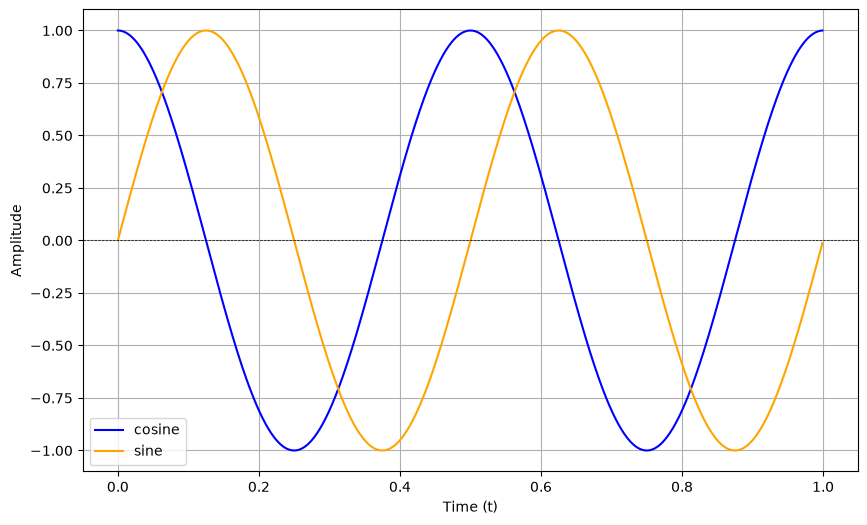

In [3]:
T = 1/2 # Period
omega = 2 * np.pi / T  # Angular frequency
nContinuousSamples = 1000 # for plotting
tPlot = np.linspace(0,1,nContinuousSamples,endpoint = False)
# Generate cosine and sine values
cosine_wave = np.cos(omega * tPlot)
sine_wave = np.sin(omega * tPlot)

# Plot the waves
plt.figure(figsize=(10, 6))
plt.plot(tPlot, cosine_wave, label='cosine', color='blue')
plt.plot(tPlot, sine_wave, label='sine', color='orange')
plt.xlabel('Time (t)')
plt.ylabel('Amplitude')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid(True)
plt.show()

### Repeating band-limited signals

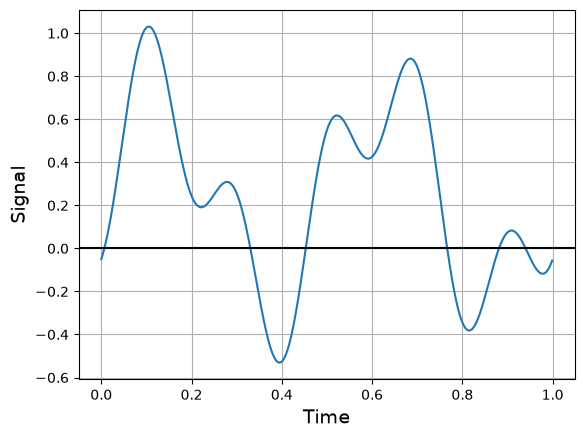

In [4]:

example = 3
if (example == 1):
	c = [0]
	s = [0, 0.5]
elif (example == 2):
	c = [0]
	s = [0, -0.3]
elif (example == 3):
	c = [0.25, 0 , 0, 0,0,-0.3]
	s = [0, 0, 0.5]
else:
	c = [-0.6*2/np.pi]
	s = [0.6]


T = 1
nContinuousSamples = 1000 # for plotting
tPlot = np.linspace(0,T,nContinuousSamples,endpoint = False)
yPlot = trignometricSignal(tPlot,c,s)
plt.plot(tPlot,yPlot)
plt.axhline(0, color='black')
plt.xlabel('Time', fontsize=14)
plt.ylabel('Signal', fontsize=14)
plt.grid(visible=True)

### Repeating signal that is not band-limited

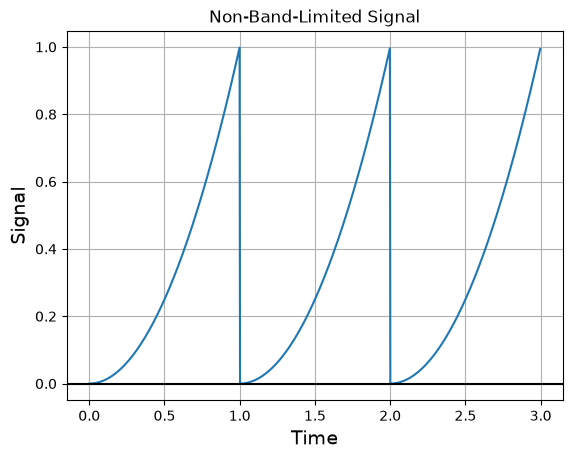

In [5]:
def non_band_limited_signal(t):
    signal = ((t-1) % 1)**2 
    return signal


nContinuousSamples = 1000  # For plotting
tPlot = np.linspace(0, 3, nContinuousSamples, endpoint=False)
yPlot = non_band_limited_signal(tPlot)

plt.plot(tPlot, yPlot)
plt.axhline(0, color='black')
plt.xlabel('Time', fontsize=14)
plt.ylabel('Signal', fontsize=14)
plt.title('Non-Band-Limited Signal')
plt.grid(visible=True)
plt.show()

## Continuous Signal

[0.25, 0, 0, 0, 0, -0.3] [0, 0, 0.5]


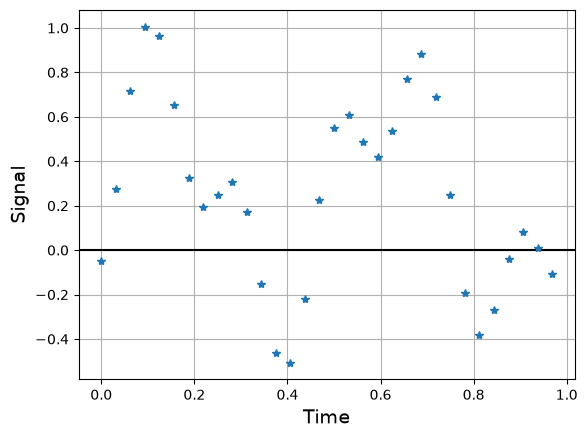

In [6]:

T = 1
c = [0.25, 0 , 0, 0,0,-0.3]
s = [0, 0, 0.5]
N = 32 # We set the number of discrete samples here
t = np.linspace(0,T,N,endpoint = False) # need to eliminate the last point
yDigital = trignometricSignal(t,c,s)
print(c,s)
plt.figure()
plt.axhline(0, color='black')
plt.xlabel('Time', fontsize=14)
plt.ylabel('Signal', fontsize=14)
plt.grid(visible=True)
plt.plot(t,yDigital,'*')

## DFT Signal Processing

Number of samples N: 32


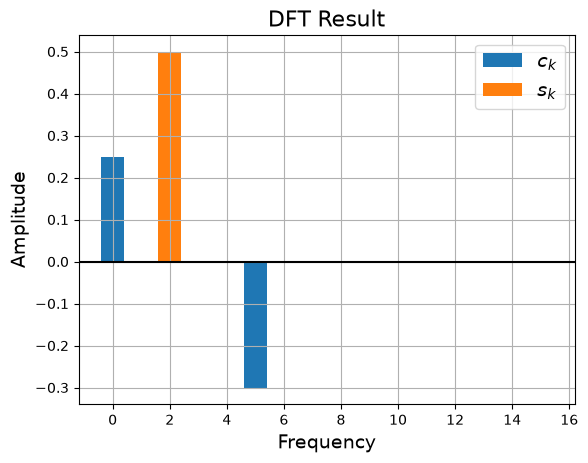

In [7]:

N = len(yDigital)
print("Number of samples N:", N)
DFTMatrix = createDFTMatrix(N)
phi = np.matmul(DFTMatrix,yDigital)

[c,s] = processDFTResult(phi)
 
plotDFTResult(c,s,N)


## QFT with 2 qubits

[[ 5.000000e-01+0.j   5.000000e-01+0.j   5.000000e-01+0.j
   5.000000e-01+0.j ]
 [ 5.000000e-01+0.j   3.061617e-17+0.5j -5.000000e-01+0.j
  -3.061617e-17-0.5j]
 [ 5.000000e-01+0.j  -5.000000e-01+0.j   5.000000e-01+0.j
  -5.000000e-01+0.j ]
 [ 5.000000e-01+0.j  -3.061617e-17-0.5j -5.000000e-01+0.j
   3.061617e-17+0.5j]]
Counts: {'00': 237, '11': 255, '01': 248, '10': 260}


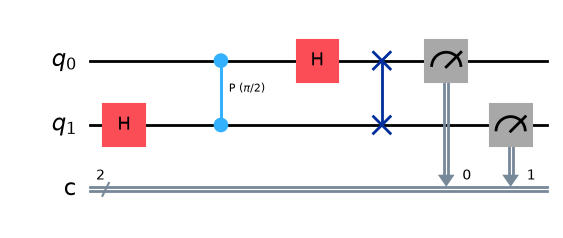

In [8]:
circuit = QuantumCircuit(2, 2)  
circuit.h(1)
circuit.cp(np.pi/2,0,1) 
circuit.h(0) 
circuit.swap(0,1)
print(np.array(Operator(circuit).data))
circuit.measure([0,1], [0,1]) 
counts = simulate_measurements(circuit,shots = 1000)
print('Counts:',counts)
circuit.draw('mpl') 

## Qiskit's QFTGate

U from circuit:
 [[ 5.00000000e-01+0.0000000e+00j  5.00000000e-01+0.0000000e+00j
   5.00000000e-01+0.0000000e+00j  5.00000000e-01+0.0000000e+00j]
 [ 5.00000000e-01+0.0000000e+00j  3.06161700e-17+5.0000000e-01j
  -5.00000000e-01+6.1232340e-17j -9.18485099e-17-5.0000000e-01j]
 [ 5.00000000e-01+0.0000000e+00j -5.00000000e-01+6.1232340e-17j
   5.00000000e-01-1.2246468e-16j -5.00000000e-01+1.8369702e-16j]
 [ 5.00000000e-01+0.0000000e+00j -9.18485099e-17-5.0000000e-01j
  -5.00000000e-01+1.8369702e-16j  2.75545530e-16+5.0000000e-01j]]


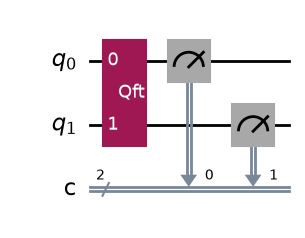

In [9]:
m = 2 # number of qubits
circuit = QuantumCircuit(m, m) 
qft = QFTGate(num_qubits=m)
UFromCircuit = Operator(qft)
print("U from circuit:\n", UFromCircuit.data)
circuit.append(qft, qargs=list(range(m)))
circuit.measure(list(range(m)),list(range(m))) 
circuit.draw('mpl')


## QFTGate

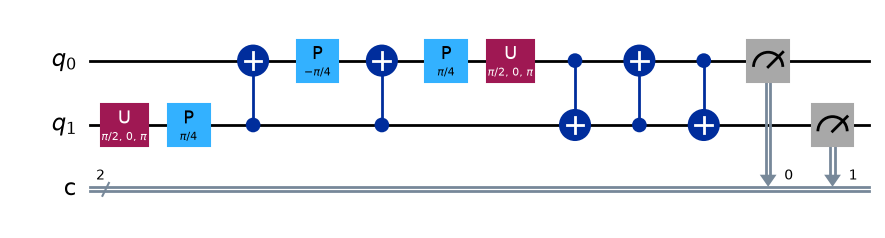

In [10]:
m = 2 # number of qubits
circuit = QuantumCircuit(m, m) 
qft = QFTGate(num_qubits=m)
circuit.append(qft, qargs=list(range(m)))
circuit.measure(list(range(m)),list(range(m))) 
circuit.decompose(reps=2).draw('mpl')


## QFT Signal Processing using Qiskit's QFTGate

Number of qubits: 5


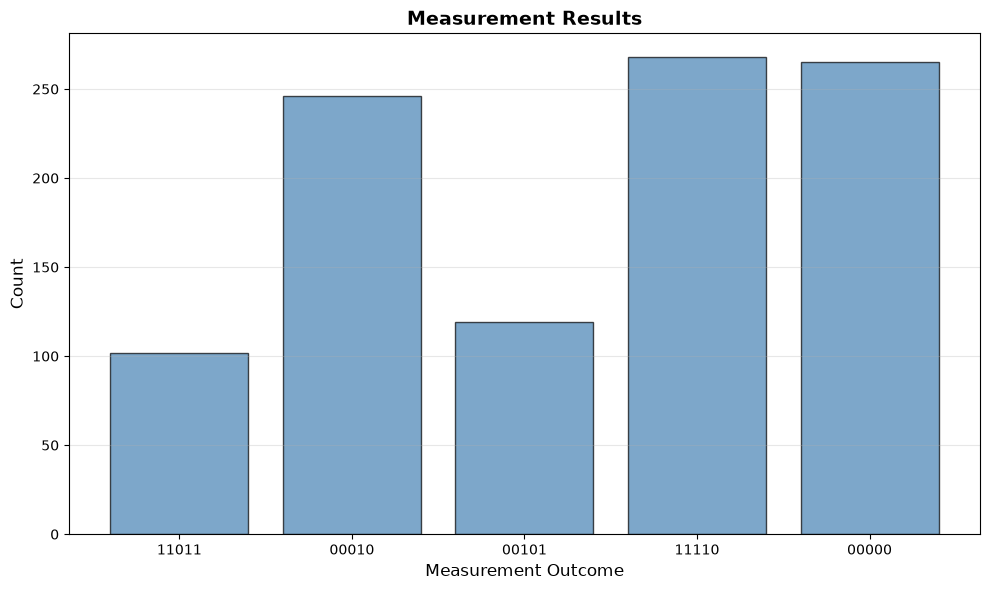

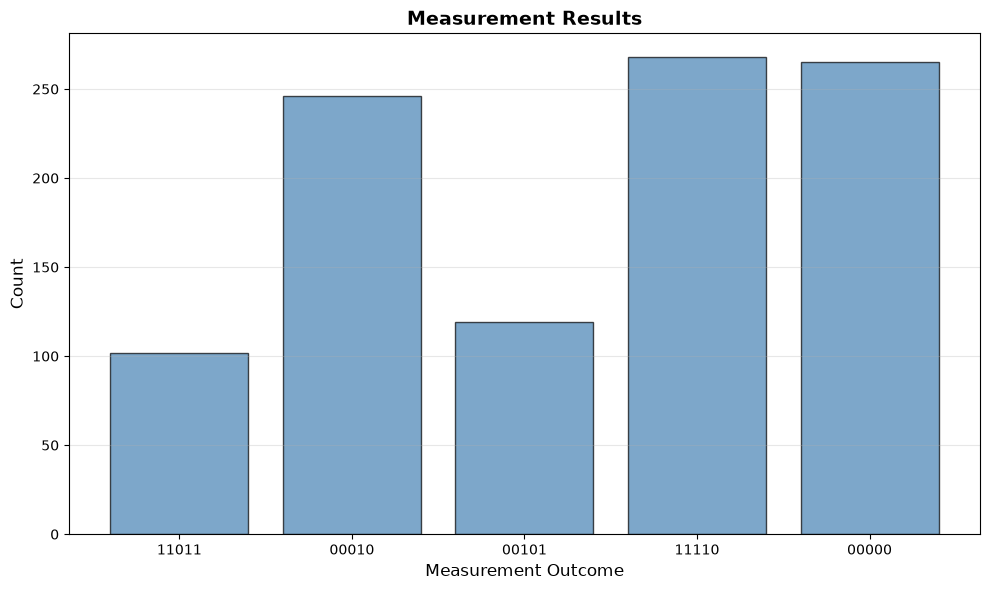

In [11]:
N = 32
t = np.linspace(0,1,N,endpoint = False) # need to eliminate the last point
y = trignometricSignal(t,c,s)
shots = 1000
counts = QFTSignalProcessing(y,shots)
plot_measurement_results(counts)

### Processing QFT results

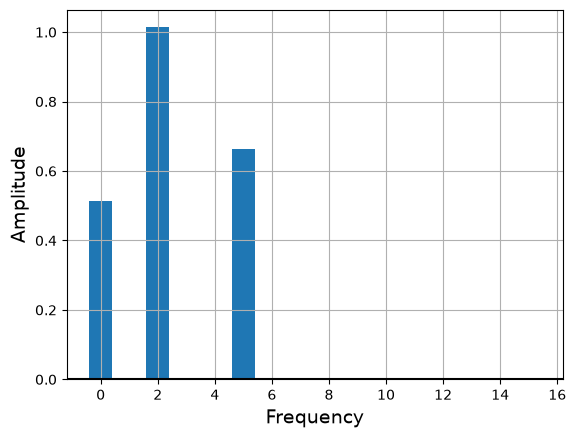

In [12]:


ampl = processQFTResult(N, counts,shots)

plt.figure()
plt.bar(list(range(0,int(N/2))),ampl)
plt.axhline(0, color='black')
plt.xlabel('Frequency', fontsize=14)
plt.ylabel('Amplitude', fontsize=14)
plt.grid(visible=True)
plt.show()

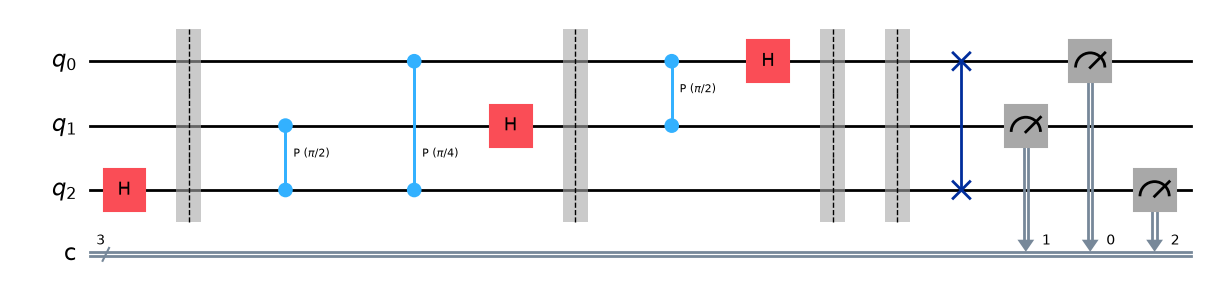

In [13]:

m = 3
circuit = myQFT(m)
circuit.measure(list(range(m)),list(range(m))) 
circuit.draw('mpl') 

### QFT Matrix Verification

In [14]:


m = 2
circuit = myQFT(m)
UFromCircuit = Operator(circuit)
UExact = createQFTMatrix(2**m)
print("Error: ", round(np.linalg.norm(UFromCircuit-UExact),10))

Error:  0.0


## Inverse QFT

<IPython.core.display.Latex object>

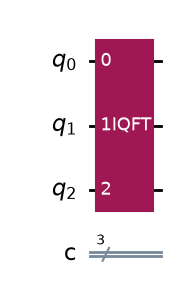

In [15]:
m = 3 # number of qubits
circuit = QuantumCircuit(m, m) 
iqft = QFTGate(num_qubits=m).inverse()
iqft._name = 'IQFT'
circuit.append(iqft, qargs=list(range(m)))

psi = Statevector(circuit)
display(psi.draw('latex'))
circuit.draw('mpl')

### 1D Poisson Solver

In [16]:
from Chapter16_QFT_functions import (spectralPoissonCircuit,
         spectralComplianceQuantum, spectralComplianceExact,
         spectralComplianceClassical)

# # Uniform load f = 1: compliance converges to the exact value 1/12
m = 4; N = 2**m
f = np.ones(N)
circuit, _ = spectralPoissonCircuit(f)
circuit.draw('mpl')
#
c_quantum,  P = spectralComplianceQuantum(f, shots=100000)
c_exact,   _  = spectralComplianceExact(f)
c_classical   = spectralComplianceClassical(f)
print(f"quantum={c_quantum:.5f}  exact={c_exact:.5f}  "
       f"classical={c_classical:.5f}  (1/12={1/12:.5f})")

quantum=0.08318  exact=0.08304  classical=0.08304  (1/12=0.08333)


### 1D Periodic Poisson Solver
The periodic (ring) problem is diagonalized by the **bare QFT** -- no sine transform, no odd extension. The circulant operator has eigenvalues $4\sin^2(\pi k/N)$ with a null mode at $k=0$, which the eigenvalue-inversion rotation simply skips. For the self-equilibrated load $f(x)=\sin(2\pi x)$ the compliance converges to the continuum value $1/(8\pi^2)$.

In [17]:
from Chapter16_QFT_functions import (spectralPoissonCircuitPeriodic,
         spectralComplianceQuantumPeriodic, spectralComplianceExactPeriodic,
         spectralComplianceClassicalPeriodic)

m = 4; N = 2**m
x = np.arange(N)/N
f = np.sin(2*np.pi*x)                      # self-equilibrated load
circuit, _ = spectralPoissonCircuitPeriodic(f)
circuit.draw('mpl')
#
c_quantum, P  = spectralComplianceQuantumPeriodic(f, shots=100000)
c_exact,   _  = spectralComplianceExactPeriodic(f)
c_classical   = spectralComplianceClassicalPeriodic(f)
print(f"quantum={c_quantum:.5f}  exact={c_exact:.5f}  "
      f"classical={c_classical:.5f}  (1/(8pi^2)={1/(8*np.pi**2):.5f})")

quantum=0.01283  exact=0.01283  classical=0.01283  (1/(8pi^2)=0.01267)


### Square load: when the transform is essential
The sine load is sparse in the frequency domain, so both QFTs can be skipped. A **square wave** is the opposite: cheap in the nodal domain (two values, encoded by PyEncode's `WALSH` constructor in $O(m)$ gates) but **dense** in frequency (a Dirichlet kernel, all odd harmonics decaying as $1/k$). There is no sparse spectrum to hand the solver, so the forward QFT does the real work. Compliance has no closed form, so we check against the classical solve numerically.

Requires PyEncode: `pip install git+https://github.com/UW-ERSL/PyEncode.git`

In [18]:
from pyencode import encode, WALSH
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFTGate, UCRYGate
from qiskit.quantum_info import Statevector
from Chapter16_QFT_functions import (periodicPoissonEigen, simulate_measurements,
        complianceFromProbabilityPeriodic, spectralComplianceClassicalPeriodic)

m = 6; N = 2**m
enc, _ = encode(WALSH(m-1, 1.0, -1.0), N=N)     # +/-1 square wave, O(m) gates
f = np.sign(Statevector(enc).data.real)         # load values in {+1, -1}

lam = periodicPoissonEigen(N); nz = lam > 1e-12; lam_min = lam[nz].min()
angles = np.zeros(N); angles[nz] = 2*np.arcsin(np.sqrt(lam_min/lam[nz]))

q = QuantumRegister(m,'q'); a = QuantumRegister(1,'a'); c = ClassicalRegister(1,'c')
qc = QuantumCircuit(q, a, c)
qc.compose(enc, q, inplace=True)                # PyEncode prepares the load
qc.append(QFTGate(num_qubits=m), list(q))       # forward QFT: now doing real work
qc.append(UCRYGate(list(angles)), [a[0]] + list(q))
qc.measure(a[0], c[0])

P = simulate_measurements(qc, shots=100000).get('1', 0)/100000
print(f"quantum={complianceFromProbabilityPeriodic(f, P, lam_min):.5f}  "
      f"classical={spectralComplianceClassicalPeriodic(f):.5f}")

quantum=0.02085  classical=0.02087


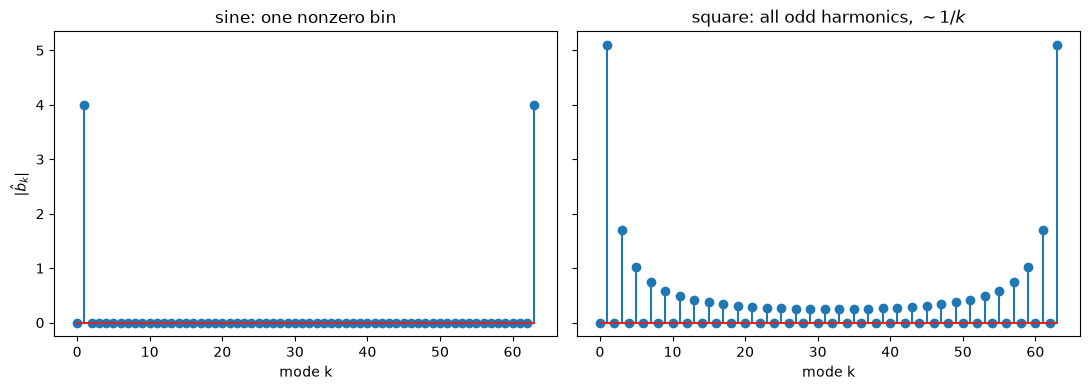

In [19]:
# Two spectra side by side: sine (one spike) vs square (dense 1/k tail)
import matplotlib.pyplot as plt
N = 64; k = np.arange(N)
sine   = np.sin(2*np.pi*k/N)
square = np.where(k < N//2, 1.0, -1.0)          # matches WALSH(m-1, +1, -1)
Bs = np.abs(np.fft.fft(sine)  /np.sqrt(N))
Bq = np.abs(np.fft.fft(square)/np.sqrt(N))
fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
ax[0].stem(k, Bs); ax[0].set_title('sine: one nonzero bin')
ax[0].set_xlabel('mode k'); ax[0].set_ylabel(r'$|\hat b_k|$')
ax[1].stem(k, Bq); ax[1].set_title(r'square: all odd harmonics, $\sim 1/k$')
ax[1].set_xlabel('mode k')
plt.tight_layout(); plt.savefig('SquareVsSineSpectrum.png', dpi=150, bbox_inches='tight')
plt.show()